# 0.머신러닝(Machine Learning)

## 0.1.선형 모델 (Linear Algorithm)
- X(문제, 독립변수), y(정답, 종속변수) 간의 선형 관계를 학습해서 모델링하는 방법
- 선형 함수를 완성해서 예측을 수행
- 분류(Classification), 회귀(Regression) 가능
- 단순 : y = wX + b
- 다중 : y = wX + wX + wX + ... + b


## 0.2.경사하강법 알고리즘(Gradient Decent Algorithm, 최적화 함수, Optimizer)
- 1)파라미터초기화(w, b) 초기화
- 2)예측: 현재의 w와 b를 사용해서 예측
- 3)오차(잔차) 계산: 손실값, Loss, Cost, Residual 등
- 4)기울기 계산: 편미분(Partial Diffrence); w와 b값을 어디로 업데이터해야 하는지 알려주는 용도(방향)
- 5)파라미터 업데이트(학습률-직접설정해야함 hyper-parameter)
- 1순환(cycle)을 에포크(epoch) 라고한다
- epoch수는 hyperpara

# 1.딥러닝(Deep Learning)이란?
- 인간의 신경망을 모방하여, 학습/예측하는 기술
  - 시각지능: 이미지, 영상 처리
  - 언어지능: 자연어(텍스트, 음성) 처리
- TensorFlow, PyTorch(객체지향) Library를 많이 사용한다.


In [2]:
# Google colab 사용시 마운트 시켜줘야한다.

# from google.colab import drive
# drive.mount('/content/drive')

# colab 사용시 change drive 해줘야한다.
# %cd /content/drive/MyDrive/Colab Notebooks/Deep_Learning

# 2.목표
- 공부시간에 따른 학생의 수학 최종 성적을 예측하는 회귀 모델 만들기 => 머신러닝 vs 딥러닝 비교

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
## 데이터 로드
pd.read_csv("./data/student-mat.csv", delimiter =";")
# Csv = c는 컴마를 의미한다.
# tsv = t 는 tap으로 구분된다
# 구분기호는 세미콜론이다. => delimiter = ";"

# data 변수에 넣기
data =  pd.read_csv("./data/student-mat.csv", delimiter =";")

# data 3개만 불러오기
data.head(3)

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10


- 종속변수는 G3이다.

| 컬럼 이름       | 설명                             |
|-----------------|----------------------------------|
| school          | 학교 (GP - Gabriel Pereira, MS - Mousinho da Silveira) |
| sex             | 성별 (F - Female, M - Male)      |
| age             | 나이                             |
| address         | 주소 유형 (U - Urban, R - Rural) |
| famsize         | 가족 크기 (LE3 - 3명 이하, GT3 - 3명 초과) |
| Pstatus         | 부모 동거 상태 (T - 함께, A - 별거) |
| Medu            | 어머니 교육 수준 (0 - 없음, 1 - 초등, 2 - 중등, 3 - 고등, 4 - 대졸) |
| Fedu            | 아버지 교육 수준 (0 - 없음, 1 - 초등, 2 - 중등, 3 - 고등, 4 - 대졸) |
| Mjob            | 어머니 직업 (teacher, health, services, at_home, other) |
| Fjob            | 아버지 직업 (teacher, health, services, at_home, other) |
| reason          | 학교 선택 이유 (home, reputation, course, other) |
| guardian        | 보호자 (mother, father, other)  |
| traveltime      | 통학 시간 (1 - 15분 이하, 2 - 15~30분, 3 - 30분~1시간, 4 - 1시간 초과) |
| studytime       | 주간 공부 시간 (1 - 2시간 이하, 2 - 2~5시간, 3 - 5~10시간, 4 - 10시간 초과) |
| failures        | 과목 낙제 수 (n if 1<=n<3, else 4) |
| schoolsup       | 학교 추가 지원 (yes, no)        |
| famsup          | 가족 추가 지원 (yes, no)        |
| paid            | 과외 수업 참여 (yes, no)        |
| activities      | 학교 외 활동 참여 (yes, no)     |
| nursery         | 유치원 참여 여부 (yes, no)      |
| higher          | 고등교육 희망 여부 (yes, no)    |
| internet        | 가정 내 인터넷 접속 여부 (yes, no) |
| romantic        | 로맨틱 관계 여부 (yes, no)      |
| famrel          | 가족 관계의 질 (1 - 매우 나쁨, 5 - 매우 좋음) |
| freetime        | 여가 시간의 양 (1 - 매우 적음, 5 - 매우 많음) |
| goout           | 외출 빈도 (1 - 매우 적음, 5 - 매우 많음) |
| Dalc            | 평일 음주량 (1 - 매우 적음, 5 - 매우 많음) |
| Walc            | 주말 음주량 (1 - 매우 적음, 5 - 매우 많음) |
| health          | 현재 건강 상태 (1 - 매우 나쁨, 5 - 매우 좋음) |
| absences        | 결석 일수                        |
| G1              | 1학기 성적                       |
| G2              | 2학기 성적                       |
| G3              | 최종 성적                        |

In [5]:
# 결측치(NaN)가 있으면 학습되지 않는다.
data.info()

# Dtype은 숫자만 학습을 할 수 있다
# object는 학습이 불가능하다.  => 나중에 인코딩 필요할 듯
# 스마트 인재개발원에서 7정의: 문제정의, Data 수집, 전처리, 탐색적데이터분석EDA, 모델 비교(CV, hyper-parameter선택), 학습, 평가

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

# 3.데이터 분할

In [6]:
# studytime 열접근하면 Series 자료형이다. 1차원 => model은 2차원 이상을 data로 받아야한다.
# type(data["studytime"])
X = data["studytime"] # =>1차원이라 대문자라고 쓴다고함

# 멀티인덱스로 2차원으로 만든다 .
X = data[["studytime"]]

# 종속변수는 G3 => 여긴 왜 1차원이냐?
y = data["G3"]

In [7]:
X.shape, y.shape

((395, 1), (395,))

In [8]:
# data set 설정하기
from sklearn.model_selection import train_test_split

# random_state 뭘 의미하지?
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.3, random_state= 2025)

In [9]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((276, 1), (119, 1), (276,), (119,))

# 4.기존의 머신러닝과의 비교

## 4.1.공통점
  - 학습 알고리즘 Logic이 비슷하다

# 4.2.차이점
  - 규칙 기반 전문가 시스템(Rule-based expert system)
    - 모든 규칙을 조건문으로 사람들이 다 규칙을 작성해줘야한다.
  - 기존 머신러닝(machine Learning)
  - 딥러닝(Deep Learning)

## 4.3.머신러닝이 더 적합한 상황
- 데이터 양이 적을 때
- 해석 가능성이 중요한 경우
- 특징이 잘 정의된 경우
  - 굳이 딥 러닝 쓰기에는 컴퓨터 자원이 아깝다.
- 연산 자원이 제한되는 경우
- 비선형성이 강하지 않은 경우

# 5.머신러닝 모델링

In [10]:
# 선형회귀 모델 해보기
from sklearn.linear_model import LinearRegression
# OLS (최적O) , RSSX => 이것이 기본인 모델


In [11]:
# 초기화(생성)후 변수에 담아주기
linear_model = LinearRegression()

# 학습
linear_model.fit(X_train, y_train)

# 평가 => 기본적인 Clasification은 => score() : Accurancy = 맞춘거(TP,FN) /전체(TP,TF,FP,FN)
# 평가 => 기본적인 Regression은 => score() : Determind Coefficient 결정계수(R^2) 0~1 값이다.
linear_model.score(X_test, y_test)

# 평가지표
# 분류 평가 지표 와 회귀 평가 지표가 다르다
# 정확도 Accuracy = 맞춘거(TP,FN) /전체(TP,TN,FP,FN)
# 혼돈행렬 True,False// Positive,Negative  => 회귀에는 적용이 불가능하다. => 분류에서만 가능하다!

# 회귀모델은 실수라서 혼동행렬이 안된다.
# 별도의 평가 지표가 필요하다. MSE (Mean Squeard Error),R^2(Determind Coefficient결정계수) 사용해야한다.


-0.029081838416823214

In [12]:
# 예측
linear_model.predict(X_test)

array([ 9.49826179, 10.31333132, 10.31333132,  9.49826179, 10.31333132,
        9.49826179,  9.49826179, 11.12840085,  9.49826179, 11.12840085,
       10.31333132, 10.31333132, 10.31333132, 10.31333132, 10.31333132,
       10.31333132, 10.31333132, 10.31333132, 10.31333132, 11.12840085,
       11.94347037,  9.49826179, 10.31333132, 11.12840085, 10.31333132,
       10.31333132, 11.12840085, 10.31333132,  9.49826179, 11.12840085,
        9.49826179, 10.31333132, 11.12840085, 10.31333132, 10.31333132,
       11.12840085,  9.49826179,  9.49826179, 10.31333132, 10.31333132,
        9.49826179,  9.49826179, 10.31333132, 10.31333132, 10.31333132,
       10.31333132, 10.31333132, 10.31333132,  9.49826179, 11.12840085,
       11.94347037, 11.94347037, 10.31333132, 10.31333132, 11.12840085,
        9.49826179,  9.49826179, 10.31333132, 11.94347037, 10.31333132,
       10.31333132, 10.31333132,  9.49826179, 10.31333132, 11.12840085,
       10.31333132, 11.12840085, 11.12840085, 10.31333132,  9.49

## 5.1.머신러닝(sklearn) vs 딥러닝(tensorflow)
> - 머신러닝
   - 생성(완성된 객체 초기화)-> 학습-> 예측-> 평가
   - 이미 만들어져 있는 알고리즘(모델)을 가져다가 하이퍼파라미터만 조정(또는 성능을 올리기 위해선 특성공학을 집중)하는 형태로 수행

> - 딥러닝
    - 생성(모델을 직접 구성)-> 학습-> 예측-> 평가
    - Tensorflow: 딥러닝 프레임워크(구글에서 만든것)
    - TensorFlow+ Keras 2버전부터는 병합(미리학습시킨거) ; PyTorch(전이학습, 파인튜닝); 이외는 인프라 구축이 약하다.
    - 직접학습 => 전이학습, 파인튜닝
    - Keras: Tensorflow 위에서 작동하는 사용자 친화적 라이브러리
    - 직접 모델의 구성을 설계해서 학습/예측하는게 가능 => 유연성 up

# 6.딥러닝 모델링 => 다음시간에 여기부터 시작

In [13]:
# 도구 불러오기 라이브러리.모듈.클래스
from tensorflow.keras.models import Sequential  # 뼈대
from tensorflow.keras.layers import InputLayer, Dense # 쌓아줄 층들

# InputLayer: 입력층 구성
# Dense(완전연결층):중간층(가중치 weight), 출력층 구성
# flow => 1.신경망 구조 설계 => 2.학습 방법 설정=> 3.학습=> 4.평가/예측

In [14]:
X_train.iloc[0].shape

(1,)

In [20]:
# 1.신경망 구조 설계

## 1.1.뼈대 생성 => sequential 초기화
model = Sequential()

## 1.2.입력층: 입력 모양을 정하는 역할 => foctor 9개 넣으면 dimension이 불규칙하므로 에러가 난다네 => 데이터 1ea의 모양을 설정(차원설정)
model.add(InputLayer(shape= (1,)))

## 1.3.은닉층(중간층) => 실질적인 연산을 담당한다 =>
### units 개수는 정답이 없다 -> 다만, 일반적인 경험에 의하면 항아리 모양이 대세다
### activation: 활성화 함수(다음 층으로 정보를 넘길지 말지) -> 비선형성 패턴을 찾기 위함
### parameter 인자 => units(Node, 노드갯수) * activation(function모양, sigmoid)
model.add(Dense(units= 64 , activation= "sigmoid"))
model.add(Dense(units= 128 , activation= "sigmoid"))
model.add(Dense(units= 256 , activation= "sigmoid"))
model.add(Dense(units= 128 , activation= "sigmoid"))
model.add(Dense(units= 64 , activation= "sigmoid"))

## 1.4.출력층: 출력 모양을 정하는 역할 - 회귀 // 이진 분류// 다중 분류
### units는 출력은 1개로 나와야한다.
### 입력층의 activation과 출력층의 activation의 역할은 다르다 => 가중합Weighted Sum (output에서 그대로 내보내면 => 회귀// 어떻게 => Binary 분류// 어떻게 => Multi 분류)
model.add(Dense(units = 1, activation="linear" ))

# Regression : 1ea, linear(항등함수)
# Binary,Binomial Classification: sigmoid(시그모이드): 0~1 확률값을 반환
# Multi Classification: 클래스 개수만큼, softmax: 각 클래스의 확률값을 반환(총합이 1이 되도록)

In [21]:
# 2.학습 방법 설정 => 컴파일에서는 loss function, optimizer, performance measure 설정해줘야한다.
model.compile(
    loss = "mean_squared_error",
    optimizer = "SGD", # 가장 기본적인 경사하강법(최적화 함수)
    metrics = ["mse"]
)

# Regression: loss = MSE(mean_squared_error, 평균제곱오차)=> sum (devi)^2 * p_i, metrics = ["mse"]
# Binary,Binomial Classification: loss="binary_crossentropy", metrics =["accuracy"]
# Multi Classification: loss="sparse_categorical_crossentropy", metrics =["accuracy"]
## categorical_crossentropy => 다차원 계산 (거의 드물다)
## sparse_categorical_crossentropy => 1차원 계산(대부분)

In [22]:
# 3.학습
h = model.fit(X_train, y_train, validation_split= 0.3, epochs= 20)

Epoch 1/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 43.0277 - mse: 43.0277 - val_loss: 26.0327 - val_mse: 26.0327
Epoch 2/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 19.9384 - mse: 19.9384 - val_loss: 21.9610 - val_mse: 21.9610
Epoch 3/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 19.6197 - mse: 19.6197 - val_loss: 23.6422 - val_mse: 23.6422
Epoch 4/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 20.0666 - mse: 20.0666 - val_loss: 21.9417 - val_mse: 21.9417
Epoch 5/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 20.0198 - mse: 20.0198 - val_loss: 23.3461 - val_mse: 23.3461
Epoch 6/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 19.9406 - mse: 19.9406 - val_loss: 22.0996 - val_mse: 22.0996
Epoch 7/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 20.3039 - mse: 20.3039 - val_loss: 22.7553 - val_mse: 22.7553
Epoch 8/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 20.6552 - mse: 20.6552 - val_loss: 22.2529 - val_mse: 22.2529
Epoch 9/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step

In [23]:
# 4.평가/예측
# score => evaluate => 복잡도(complex)
model.evaluate(X_test, y_test)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 54.0425 - mse: 54.0425 


[54.04248809814453, 54.04248809814453]

In [24]:
# evaluate보다 복잡도 검사 history를 더 많이 사용한다. => visualization
h.history.keys()

dict_keys(['loss', 'mse', 'val_loss', 'val_mse'])

In [25]:

print(h.history["loss"])

[43.02771759033203, 19.938426971435547, 19.619657516479492, 20.06658172607422, 20.0197811126709, 19.940649032592773, 20.303897857666016, 20.655214309692383, 19.731643676757812, 21.06789207458496, 22.182865142822266, 21.50926971435547, 19.659868240356445, 23.337432861328125, 19.7477970123291, 19.671937942504883, 19.95648765563965, 20.016366958618164, 20.450960159301758, 20.15922737121582]


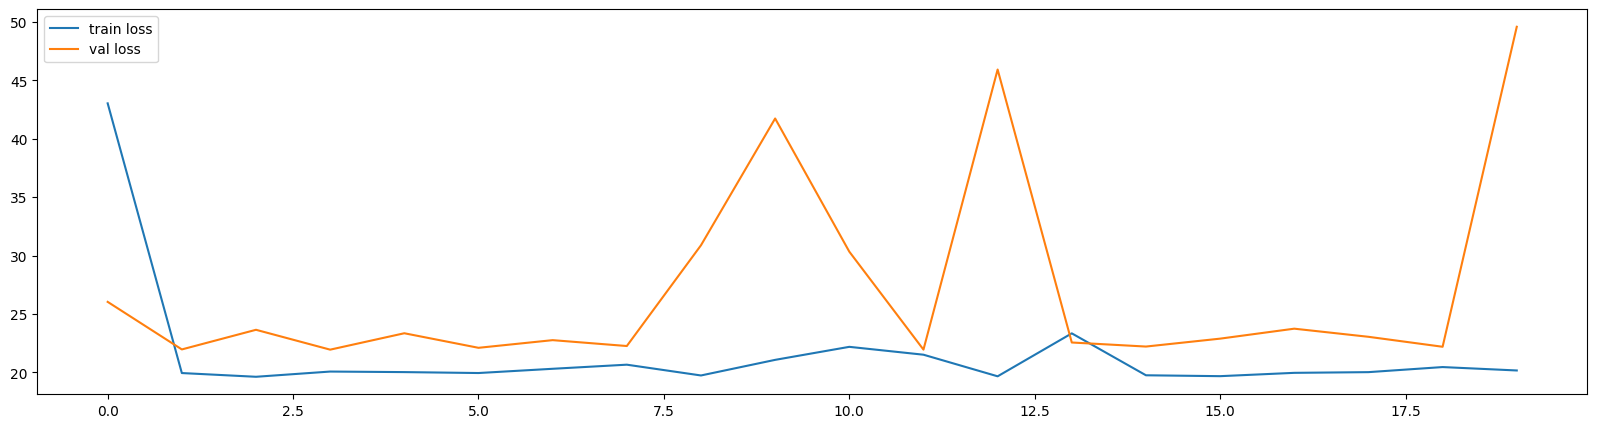

In [26]:
# 복잡도 곡선 그리기(학습결과 시각화)

plt.figure(figsize = (20,5))
plt.plot(h.history["loss"], label = "train loss") 
plt.plot(h.history["val_loss"], label = "val loss")

# 범례표시
plt.legend()


plt.show()

# 실습! 특성을 4ea 선택해서 학습

In [28]:
data.info()
# feature2 = age(나이)
# feature1 = studytime(주중 학습시간)
# feature4 = walc (주말 음주)
# feature3 = traveltime(통학시간)

# label = G3 (최종 성적)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

## 7.4개 특성 기반 회귀 실습 계획

아래 실습에서는 지정한 4개 입력 특성(feature)과 1개 라벨(label)을 사용해 두 가지 접근을 비교합니다.

선택 대상
- feature1: studytime (주중 학습시간)
- feature2: age (나이)
- feature3: traveltime (통학시간)
- feature4: Walc (주말 음주량)  ※ 데이터 컬럼은 대문자 W 로 시작 (원본 주석: walc)
- label: G3 (최종 성적)

진행 순서
1) 컬럼 존재/철자 점검 + 안전한 매핑
2) 특성/라벨 분리 (X, y)
3) 학습/평가 데이터 분할 (train/test)
4) 스케일링(StandardScaler) 적용 (딥러닝/경사하강 수렴 안정성 향상 목적)
5) (전통) 선형회귀 모델 학습 및 평가 (R^2, MSE, RMSE, MAE)
6) (딥러닝) 간단 MLP(다층 퍼셉트론) 모델 구성/학습/평가
7) 두 접근법 성능 비교 표/시각화
8) 해석 포인트 및 추가 개선 아이디어 주석

주의 사항
- 모든 특성은 현재 정수형이므로 원-핫 인코딩 불필요
- 과적합 여부: train/val 손실 곡선으로 1차 점검
- 재현성: random_state 고정

이제 아래 셀들에서 단계별로 구현합니다.

In [35]:
# 7-1. 사용할 컬럼 정의 및 존재 여부/철자 점검
# - 원본 데이터의 컬럼 이름이 정확한지 사전적으로 검증하여 이후 KeyError 방지
# - Walc 컬럼: 데이터 사양 표에서 'Walc' 로 대문자 W 임을 주석 강조

# 1) 전체 컬럼 이름 확인 (상위 10개만 미리보기 -> 너무 길면 생략)
all_columns = list(data.columns)
print(f"총 컬럼 수: {len(all_columns)}")
print(all_columns)

# 2) 목적(feature/label) 목록 선언
feature_cols_raw = ["studytime", "age", "traveltime", "Walc"]  # 선택한 4개 특성
label_col = "G3"  # 최종 성적

# 3) 존재 여부 검증
missing = [c for c in feature_cols_raw + [label_col] if c not in all_columns]
if missing:
    raise ValueError(f"다음 필요한 컬럼이 데이터에 없습니다: {missing}")
else:
    print("✅ 모든 필요한 컬럼이 데이터에 존재합니다.")

# 4) 특성/라벨 DataFrame / Series 추출
X_selected = data[feature_cols_raw].copy()
y_selected = data[label_col].copy()

# 5) 간단 기초 통계 확인
print("\n[특성 기초 통계]\n", X_selected.describe().T)
print("\n[라벨 기초 통계]\n", y_selected.describe())

# 6) 상관관계(피어슨) 확인: 회귀 설명력 힌트
corr = X_selected.assign(G3=y_selected).corr()["G3"].sort_values(ascending=False)
print("\n[G3와의 상관계수 내림차순]\n", corr)

총 컬럼 수: 33
['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']
✅ 모든 필요한 컬럼이 데이터에 존재합니다.

[특성 기초 통계]
             count       mean       std   min   25%   50%   75%   max
studytime   395.0   2.035443  0.839240   1.0   1.0   2.0   2.0   4.0
age         395.0  16.696203  1.276043  15.0  16.0  17.0  18.0  22.0
traveltime  395.0   1.448101  0.697505   1.0   1.0   1.0   2.0   4.0
Walc        395.0   2.291139  1.287897   1.0   1.0   2.0   3.0   5.0

[라벨 기초 통계]
 count    395.000000
mean      10.415190
std        4.581443
min        0.000000
25%        8.000000
50%       11.000000
75%       14.000000
max       20.000000
Name: G3, dtype: float64

[G3와의 상관계수 내림차순]
 G3            1.000000
studytime     0.097820
Walc         -0

[G3와의 상관계수 표]



,corr_with_G3
studytime,0.097820
Walc,-0.051939
traveltime,-0.117142
age,-0.161579


C:\Users\lgdx\AppData\Local\Temp\ipykernel_17632\447637891.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bar = sns.barplot(x=corr_table.index, y='corr_with_G3', data=corr_table, palette='coolwarm')


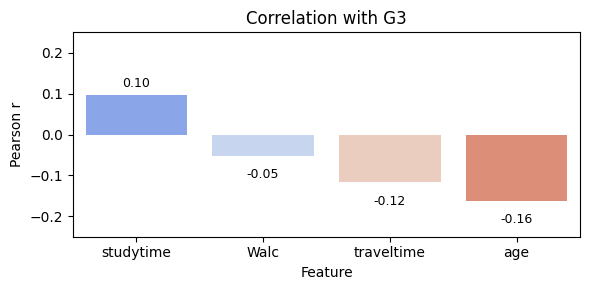

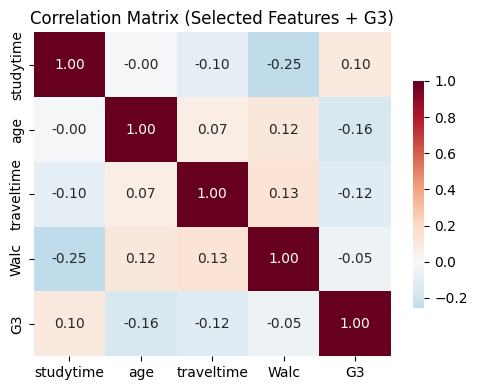


해석 참고: |r| < 0.1: 매우 약함, 0.1~0.3: 약함 (실무적 영향 낮음 가능)


In [36]:
# 7-1 추가: 선택한 4개 특성과 G3의 상관계수 상세 표/시각화
import seaborn as sns

# 1) G3와의 단일 상관계수 표 (자기 자신 G3 제외)
corr_table = (
    X_selected.assign(G3=y_selected)
    .corr()[['G3']]
    .drop(index='G3')
    .rename(columns={'G3':'corr_with_G3'})
    .sort_values('corr_with_G3', ascending=False)
)
print('[G3와의 상관계수 표]\n')
display(corr_table)

# 2) 막대그래프 (양/음 시각 구분)
plt.figure(figsize=(6,3))
bar = sns.barplot(x=corr_table.index, y='corr_with_G3', data=corr_table, palette='coolwarm')
plt.title('Correlation with G3')
plt.ylabel('Pearson r')
plt.xlabel('Feature')
# 값 주석
for p in bar.patches:
    h = p.get_height()
    plt.text(p.get_x()+p.get_width()/2, h + (0.01 if h>=0 else -0.03), f'{h:.2f}', ha='center', va='bottom' if h>=0 else 'top', fontsize=9)
plt.ylim(min(-0.25, corr_table.corr_with_G3.min()-0.05), max(0.25, corr_table.corr_with_G3.max()+0.05))
plt.tight_layout()
plt.show()

# 3) 전체 (특성 + G3) 상관 행렬 히트맵
plt.figure(figsize=(5,4))
cm = X_selected.assign(G3=y_selected).corr()
sns.heatmap(cm, annot=True, fmt='.2f', cmap='RdBu_r', center=0, cbar_kws={'shrink':0.7})
plt.title('Correlation Matrix (Selected Features + G3)')
plt.tight_layout()
plt.show()

# 해석 가이드 라인 간단 출력
print('\n해석 참고: |r| < 0.1: 매우 약함, 0.1~0.3: 약함 (실무적 영향 낮음 가능)')

In [30]:
# 7-2. Train/Test 분할 + 스케일링
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 2025  # 재현성
TEST_SIZE = 0.3

# 1) 분할
X_tr, X_te, y_tr, y_te = train_test_split(
    X_selected, y_selected, test_size=TEST_SIZE, random_state=RANDOM_STATE
)
print(f"Train shape: {X_tr.shape}, Test shape: {X_te.shape}")

# 2) 스케일링 (평균0, 분산1) -> 선형회귀/딥러닝 모두 안정적인 수렴 유도
scaler = StandardScaler()
X_tr_scaled = scaler.fit_transform(X_tr)  # ndarray 반환
X_te_scaled = scaler.transform(X_te)

# 3) 스케일러 적용 결과 간단 검증
import numpy as np
print("훈련 세트 스케일 후 각 특성 (평균, 표준편차):")
print(np.round(X_tr_scaled.mean(axis=0), 4), np.round(X_tr_scaled.std(axis=0), 4))

Train shape: (276, 4), Test shape: (119, 4)
훈련 세트 스케일 후 각 특성 (평균, 표준편차):
[-0.  0. -0. -0.] [1. 1. 1. 1.]


In [31]:
# 7-3. (전통) 선형회귀 모델 학습 & 평가
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

lin_reg = LinearRegression()
lin_reg.fit(X_tr_scaled, y_tr)

# 예측
y_tr_pred = lin_reg.predict(X_tr_scaled)
y_te_pred = lin_reg.predict(X_te_scaled)

# 평가지표 계산 함수
def regression_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = mse ** 0.5
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return {"MSE": mse, "RMSE": rmse, "MAE": mae, "R2": r2}

metrics_lin_train = regression_metrics(y_tr, y_tr_pred)
metrics_lin_test = regression_metrics(y_te, y_te_pred)
print("[LinearRegression - Train]", metrics_lin_train)
print("[LinearRegression - Test ]", metrics_lin_test)

# 계수(특성 중요도 유사 개념) 해석
coef_df = pd.DataFrame({
    "feature": feature_cols_raw,
    "coefficient": lin_reg.coef_
}).sort_values("coefficient", key=abs, ascending=False)
print("\n[선형 회귀 계수 (절대값 기준 내림차순)]\n", coef_df)
print(f"Intercept (절편 b): {lin_reg.intercept_:.4f}")

[LinearRegression - Train] {'MSE': 19.069684884296215, 'RMSE': 4.366885032182117, 'MAE': 3.286944379112018, 'R2': 0.05772457323378455}
[LinearRegression - Test ] {'MSE': 23.03685498338375, 'RMSE': 4.799672382921958, 'MAE': 3.6284152142706896, 'R2': -0.023424991434559672}

[선형 회귀 계수 (절대값 기준 내림차순)]
       feature  coefficient
0   studytime     0.549858
1         age    -0.490026
2  traveltime    -0.428333
3        Walc    -0.423802
Intercept (절편 b): 10.3370


[MLP - Test] MSE: 29.7275, RMSE: 5.4523
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
[MLP - Train] {'MSE': 21.2759952545166, 'RMSE': 4.612590948102444, 'MAE': 3.5800745487213135, 'R2': -0.05129408836364746}
[MLP - Test ] {'MSE': 29.727540969848633, 'RMSE': 5.452296852689574, 'MAE': 4.236286640167236, 'R2': -0.320662260055542}


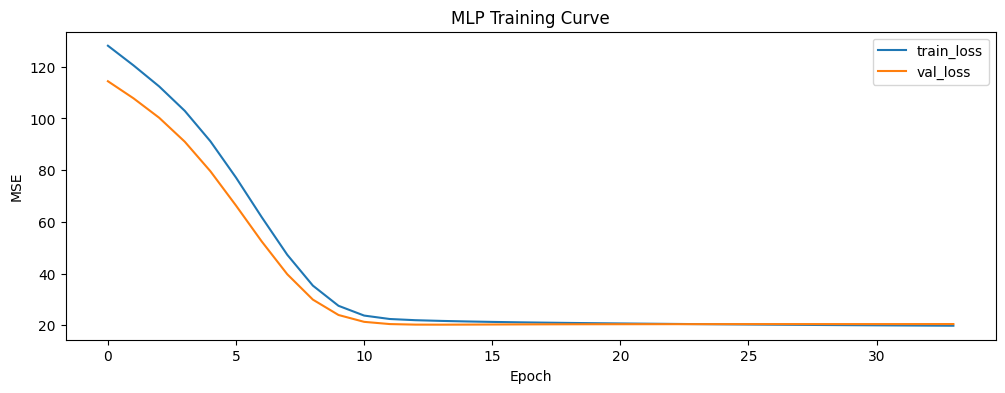

In [33]:
# 7-4. (딥러닝) 간단 MLP 회귀 모델
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, InputLayer
from tensorflow.keras.callbacks import EarlyStopping

# 재현성(가능한 범위 내)
SEED = 2025
np.random.seed(SEED)
import random; random.seed(SEED)
tf.random.set_seed(SEED)

mlp = Sequential([
    InputLayer(shape=(len(feature_cols_raw),)),  # 입력 차원 = 4
    Dense(32, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1, activation='linear')  # 회귀 출력
])

mlp.compile(
    optimizer='adam',  # 가변 학습률 + 모멘텀 유사 효과
    loss='mse',        # 회귀 기본 손실
    metrics=['mse']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=20,             # 20 epoch 동안 개선 없으면 중단
    restore_best_weights=True
)

history = mlp.fit(
    X_tr_scaled, y_tr,
    validation_split=0.2,  # 학습 세트 내부 검증
    epochs=300,
    batch_size=16,
    callbacks=[early_stop],
    verbose=0
)

# 최종 평가
dl_test_mse, dl_test_mse_metric = mlp.evaluate(X_te_scaled, y_te, verbose=0)
print(f"[MLP - Test] MSE: {dl_test_mse:.4f}, RMSE: {dl_test_mse**0.5:.4f}")

# 예측 및 상세 지표
y_te_pred_dl = mlp.predict(X_te_scaled).ravel()
metrics_dl_test = regression_metrics(y_te, y_te_pred_dl)
metrics_dl_train = regression_metrics(y_tr, mlp.predict(X_tr_scaled).ravel())
print("[MLP - Train]", metrics_dl_train)
print("[MLP - Test ]", metrics_dl_test)

# 학습 곡선 시각화
plt.figure(figsize=(12,4))
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('MLP Training Curve')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.legend()
plt.show()

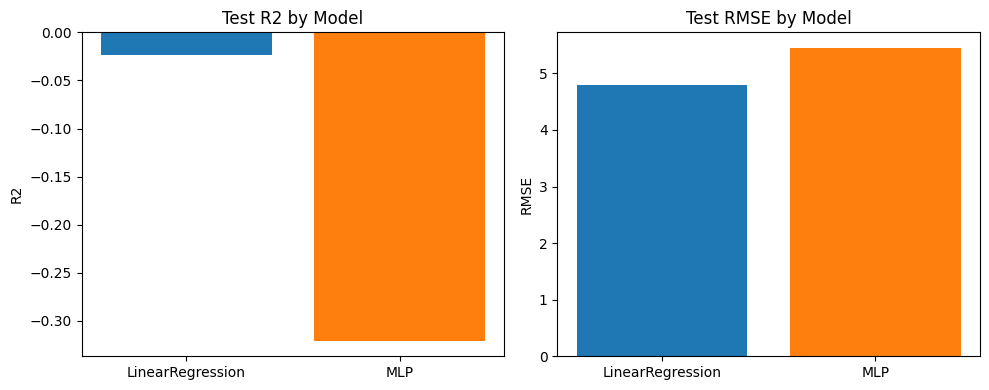

In [34]:
# 7-5. 두 모델 성능 비교 표 & 시각화
import pandas as pd

compare_df = pd.DataFrame([
    {"model": "LinearRegression", "dataset": "train", **metrics_lin_train},
    {"model": "LinearRegression", "dataset": "test", **metrics_lin_test},
    {"model": "MLP", "dataset": "train", **metrics_dl_train},
    {"model": "MLP", "dataset": "test", **metrics_dl_test},
])

compare_df

# 시각화 (R2와 RMSE 중심)
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
for m in compare_df['model'].unique():
    subset = compare_df[(compare_df.model==m) & (compare_df.dataset=='test')]
    plt.bar(m, subset['R2'].values[0])
plt.title('Test R2 by Model')
plt.ylabel('R2')

plt.subplot(1,2,2)
for m in compare_df['model'].unique():
    subset = compare_df[(compare_df.model==m) & (compare_df.dataset=='test')]
    plt.bar(m, subset['RMSE'].values[0])
plt.title('Test RMSE by Model')
plt.ylabel('RMSE')
plt.tight_layout()
plt.show()

### 7-6. 결과 해석 & 개선 아이디어

핵심 요약
- 선택한 4개 특성(studytime, age, traveltime, Walc)만으로는 G3(최종 성적)에 대한 설명력이 제한적일 수 있음 (R2 값이 낮을 가능성). 
- 선형회귀 vs MLP: 특성이 적고 비선형성이 강하지 않다면 단순 선형모델과 딥러닝 간 성능 차이가 크지 않을 수 있음.

해석 포인트
1. 계수(coefficient) 해석: 선형회귀 계수의 부호와 크기는 각 특성과 성적 간 방향성을 보여줌.
2. Walc(주말 음주)가 성적에 음영향이라면 음의 계수 / studytime은 양의 계수일 가능성.
3. traveltime 은 학습시간 감소 간접효과 가능하나 데이터 편차가 작으면 영향 미미.
4. age 는 학년/재수/낙제 등 복합 요인이 숨어 있을 수 있어 단순 영향력 제한.

개선 아이디어
- 더 많은 학업 관련 특성 추가(G1, G2 중간 성적은 강력한 예측자)
- 범주형(object) 변수 원-핫 인코딩 후 포함 (school, sex, address 등)
- 규칙 기반 이상치(outlier) 탐색 후 제거/조정
- 교차검증(K-Fold)으로 일반화 성능 재평가
- 정규화 외 RobustScaler 시도 (이상치 민감성 완화)
- 딥러닝: Dropout / BatchNormalization 추가 후 과적합 대비
- 하이퍼파라미터 튜닝 (은닉층 크기, learning rate, optimizer 변경(AdamW, RMSprop), batch_size)

다음 단계 제안
- G1/G2 추가 시 다중공선성 체크 (VIF) 및 성능 향상 여부 검증
- SHAP/Permutation Importance로 특성 기여도 직관적 시각화
- 목표(정확한 점수 예측 vs 등급화)에 따라 회귀 -> 분류 변환(예: 성적 구간화) 고려 가능

위 아이디어 중 원하는 방향이 있으면 말씀 주세요. 추가 확장 셀을 만들어 드릴 수 있습니다.

## 8. 전체 Feature vs G3 상관관계 (수치 + 범주형 원-핫 포함)

목표
- 데이터의 모든 컬럼을 대상으로 G3(최종 성적)와의 Pearson 상관계수 산출
- 범주형(object) 변수는 원-핫 인코딩(one-hot encoding) 후 개별 더미 컬럼에 대해 계산
- 가장 높은 양(+) / 음(-)의 상관을 보이는 상위 n개 특성 식별

절차
1) 수치형/범주형 컬럼 분리
2) 범주형 원-핫 인코딩 (drop_first=True로 다중공선성 일부 완화)
3) 인코딩 결과 + 수치형 합쳐 상관계수 계산
4) 상관계수 시리즈에서 G3 기준 정렬
5) Top k / Bottom k 표 + 막대그래프
6) 선택된 상위 특성 중심 히트맵 (G3 포함)

주의
- Pearson 상관은 선형(직선) 관계만 반영 => 비선형 패턴은 반영하지 못함
- 시험 점수(G1, G2)는 G3와 매우 강한 상관을 보일 것으로 예상 (중간/2학기 성적 ⇒ 최종 성적)
- 범주형 더미는 값이 0/1로 희소할 수 있어 해석 시 빈도( support ) 고려 필요

다음 코드 셀에서 구현.

수치형 컬럼 수: 16, 범주형 컬럼 수: 17
원-핫 인코딩 후 더미 컬럼 수: 26
통합 DataFrame shape: (395, 42)

[양(+)의 상관 Top]
G2                   0.904868
G1                   0.801468
Medu                 0.217147
higher_yes           0.182465
Fedu                 0.152457
Mjob_health          0.116158
address_U            0.105756
sex_M                0.103456
paid_yes             0.101996
internet_yes         0.098483
studytime            0.097820
reason_reputation    0.095692
Name: G3, dtype: float64

[음(-)의 상관 Top]
Fjob_other       -0.053483
Dalc             -0.054660
Pstatus_T        -0.058009
health           -0.061335
schoolsup_yes    -0.082788
guardian_other   -0.087774
Mjob_other       -0.096477
traveltime       -0.117142
romantic_yes     -0.129970
goout            -0.132791
age              -0.161579
failures         -0.360415
Name: G3, dtype: float64


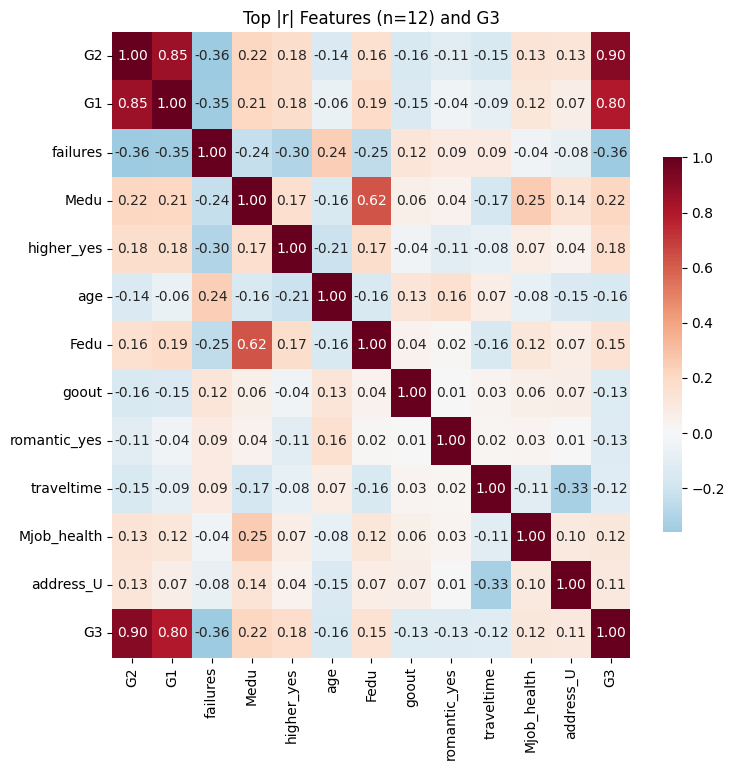

C:\Users\lgdx\AppData\Local\Temp\ipykernel_17632\815797845.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bar_ax = sns.barplot(x=rank_df.index, y='r', data=rank_df, palette='coolwarm')


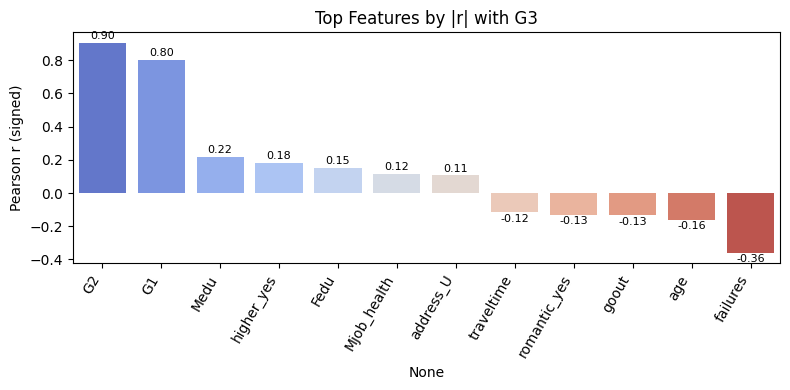


요약:
- G1, G2 등 중간 성적이 상위권에 등장하면 최종 성적과 강한 직접 연관 (누적 학업 성취 반영).
- 생활 습관/지원 변수는 상대적으로 약한 r (0.3 미만) 일 가능성이 큼.
- 범주형 더미는 특정 소수 집단에 의존할 수 있어 해석 시 빈도 확인 필요.


In [37]:
# 8-1. 전체 Feature 상관관계 계산
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

TARGET = 'G3'
TOP_K = 12  # 상위/하위 조회 개수 (양/음 각각 일부 표시)

# 1) 수치형 / 범주형 분리
numeric_cols = data.select_dtypes(include=[np.number]).columns.tolist()
if TARGET not in numeric_cols:
    raise ValueError('G3 must be numeric for Pearson correlation.')

categorical_cols = [c for c in data.columns if c not in numeric_cols]
print(f"수치형 컬럼 수: {len(numeric_cols)}, 범주형 컬럼 수: {len(categorical_cols)}")

# 2) 원-핫 인코딩 (drop_first=True 로 기준 카테고리 제거)
if categorical_cols:
    dummies = pd.get_dummies(data[categorical_cols], drop_first=True, dtype=int)
    print(f"원-핫 인코딩 후 더미 컬럼 수: {dummies.shape[1]}")
else:
    dummies = pd.DataFrame(index=data.index)

# 3) 통합 DataFrame 구성 (G3 포함)
full_df = pd.concat([data[numeric_cols], dummies], axis=1)
print(f"통합 DataFrame shape: {full_df.shape}")

# 4) 상관계수 계산 (Pearson)
#    결측이 있으면 dropna 자동 처리됨 (현재 데이터엔 없음)
correlation_series = full_df.corr()[TARGET].drop(labels=[TARGET]).sort_values(ascending=False)

# 5) Top 양의 상관 / 음의 상관 분리
positive_top = correlation_series.head(TOP_K)
negative_top = correlation_series.tail(TOP_K)

print("\n[양(+)의 상관 Top]")
print(positive_top)
print("\n[음(-)의 상관 Top]")
print(negative_top)

# 6) 상위 중요 특성(절댓값 기준) 추출 후 히트맵
abs_top_features = correlation_series.abs().sort_values(ascending=False).head(TOP_K).index.tolist()
heatmap_features = abs_top_features + [TARGET]

plt.figure(figsize=(max(6, len(heatmap_features)*0.6), 0.6*len(heatmap_features)))
cm_top = full_df[heatmap_features].corr()
sns.heatmap(cm_top, annot=True, fmt='.2f', cmap='RdBu_r', center=0, cbar_kws={'shrink':0.6})
plt.title(f'Top |r| Features (n={TOP_K}) and {TARGET}')
plt.tight_layout()
plt.show()

# 7) 막대그래프 (절댓값 기준 상위)
plt.figure(figsize=(8,4))
rank_df = correlation_series.abs().sort_values(ascending=False).head(TOP_K).to_frame(name='|r|')
rank_df['r'] = correlation_series[rank_df.index]
rank_df.sort_values('r', ascending=False, inplace=True)
bar_ax = sns.barplot(x=rank_df.index, y='r', data=rank_df, palette='coolwarm')
plt.xticks(rotation=60, ha='right')
plt.ylabel('Pearson r (signed)')
plt.title('Top Features by |r| with G3')
for p in bar_ax.patches:
    h = p.get_height()
    bar_ax.text(p.get_x()+p.get_width()/2, h + (0.01 if h>=0 else -0.01), f'{h:.2f}', ha='center', va='bottom' if h>=0 else 'top', fontsize=8)
plt.tight_layout()
plt.show()

# 8) 간단 해석 요약
print('\n요약:')
print('- G1, G2 등 중간 성적이 상위권에 등장하면 최종 성적과 강한 직접 연관 (누적 학업 성취 반영).')
print('- 생활 습관/지원 변수는 상대적으로 약한 r (0.3 미만) 일 가능성이 큼.')
print('- 범주형 더미는 특정 소수 집단에 의존할 수 있어 해석 시 빈도 확인 필요.')

# 9) 선택적: 다중공선성 위험성이 있는 상위(score가 매우 높은) 시험성적들을 동시에 사용할 경우 VIF 검사 권장 (원하면 별도 셀 추가 가능).

GitHub Copilot

### 1. 왜 Activation Function 이 필요한가?
- 선형( linear ) 계층만 여러 겹 쌓으면 결국 하나의 선형식 → 표현력 제한.
- 비선형 활성함수로 결정경계를 비틀어 복잡한 패턴( XOR 등 )을 학습.
- 출력 분포/학습 안정성(기울기 소실·폭주 방지)에도 영향.

### 2. 직관 한 줄 요약
| 함수 | 핵심 직관 | 장점 | 주의 |
|------|-----------|------|------|
| Step | 임계값 넘으면 1 | 개념적 | 미분 불가 → 학습 불가 |
| Sigmoid (σ) | S곡선 0~1 확률 | 확률 해석 | 양끝 포화 → 기울기 소실, 0-중심 아님 |
| Tanh | -1~1 S곡선 | 0 중심 | 포화 문제 여전 |
| ReLU | 0 이하면 0, 양수는 그대로 | 간단·빠름, 안포화(+) | 음수영역 dead neuron |
| Leaky ReLU | 음수도 작은 기울기 | dead 완화 | 기울기 선택 필요 |
| ELU | 음수는 완만한 음수 곡선 | 평균 0 경향 | exp 연산 비용 |
| GELU | 확률적 게이팅(부드러운 ReLU) | SOTA 자주 | 약간 느림 |
| SiLU / Swish | x * sigmoid(x) | 부드럽고 성능 양호 | 느림 가능 |
| Softmax | 벡터→확률분포 | 다중분류 출력 | 단일 스칼라엔 부적합 |

### 3. 아주 간단 수식 (z = w·x + b)
- Sigmoid: σ(z)=1/(1+e^{-z})
- Tanh: (e^{z}-e^{-z})/(e^{z}+e^{-z})
- ReLU: max(0,z)
- Leaky ReLU: max(αz, z) (α≈0.01)
- Softmax: exp(z_i)/Σ_j exp(z_j)

### 4. 선택 가이드 (실무 기본)
- 은닉층 기본: ReLU (문제 없으면 그대로)
- Dead neuron 많으면: LeakyReLU / GELU / Swish
- RNN 등 과거(전통) 코드: Tanh / Sigmoid 혼합
- 출력층:
  - 이진 분류: Sigmoid
  - 다중 분류: Softmax
  - 회귀 (실수): Linear (활성함수 없음)
  - 0~1 회귀: Sigmoid (타깃 스케일 맞추기)
  - 음수/양수 제한 없는 정규화 벡터: softmax (확률 필요할 때)

### 5. 시각화 코드 (로컬 실행)


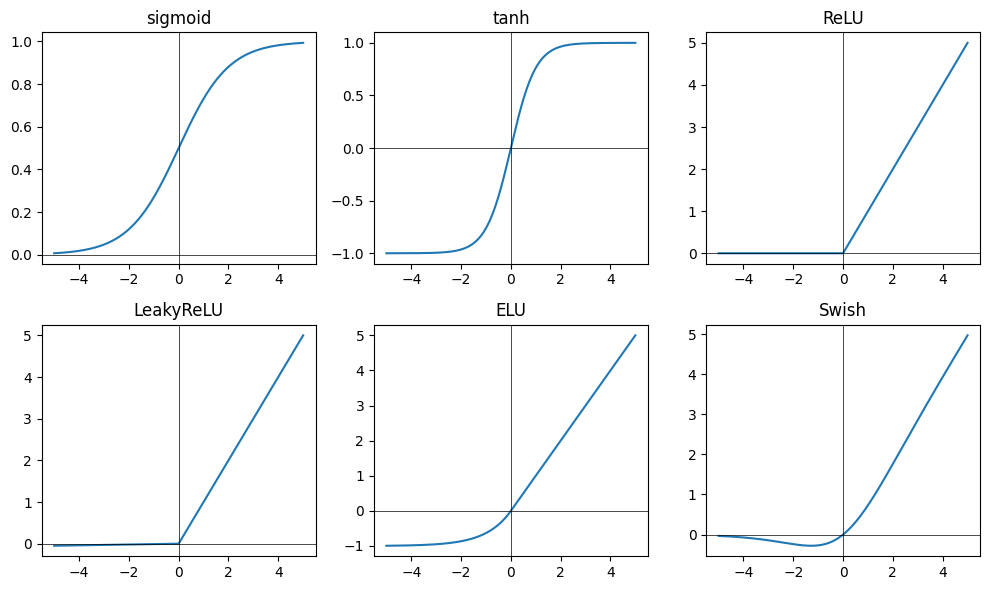

In [39]:
# ...existing code...
import numpy as np, matplotlib.pyplot as plt, math
x = np.linspace(-5,5,400)

def sigmoid(z): return 1/(1+np.exp(-z))
def tanh(z): return np.tanh(z)
def relu(z): return np.maximum(0,z)
def leaky(z, a=0.01): return np.where(z>0,z,a*z)
def elu(z, a=1.0): return np.where(z>0,z,a*(np.exp(z)-1))
def swish(z): return z*sigmoid(z)
acts = {
    "sigmoid": sigmoid(x),
    "tanh": tanh(x),
    "ReLU": relu(x),
    "LeakyReLU": leaky(x),
    "ELU": elu(x),
    "Swish": swish(x)
}

plt.figure(figsize=(10,6))
for i,(k,v) in enumerate(acts.items(),1):
    plt.subplot(2,3,i); plt.plot(x,v); plt.title(k); plt.axhline(0,color='k',lw=0.5); plt.axvline(0,color='k',lw=0.5)
    plt.tight_layout()
plt.show()



### 6. 빠른 감 잡기 예
- ReLU: “문 열어 (양수) 들어오면 그대로, 아니면 닫아(0).”
- Sigmoid: “점수 z 를 0~1 확률로 눌러준다.”
- Softmax: “여러 점수 중 상대적 크기를 확률 분포로 변환.”

### 7. 더 보기 (공식·교육 자료)
- TensorFlow Activations: https://www.tensorflow.org/api_docs/python/tf/keras/activations
- PyTorch 활성함수: https://pytorch.org/docs/stable/nn.functional.html#non-linear-activation-functions
- Stanford CS231n ActFun: https://cs231n.github.io/neural-networks-1/#actfun
- Distill (GELU 소개 논문 요약): https://arxiv.org/abs/1606.08415
- Activation Functions (Wiki): https://en.wikipedia.org/wiki/Activation_function

필요 시: 기울기 소실 데모, BatchNorm 영향, Softmax 안정화(log-sum-exp) 예제 요청 가능.